In [3]:
import SimpleITK as sitk
import numpy as np 
import matplotlib.pyplot as plt 

img_sitk = sitk.ReadImage('../../3702_left_knee.nii') 
img_sitk

<SimpleITK.SimpleITK.Image; proxy of <Swig Object of type 'itk::simple::Image *' at 0x00000152F6751800> >

In [4]:
#Converting sitk_metadata to image Array
image = sitk.GetArrayFromImage(img_sitk) 
image.shape 

(216, 512, 512)

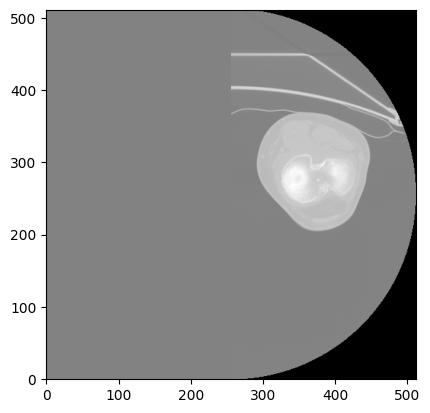

In [5]:
plt.imshow(np.squeeze(image[100, :, :]), cmap='gray',origin='lower');
plt.show()

In [6]:
print(f"Image Dimensions: {img_sitk.GetSize()}")
print(f"Voxel Spacing: {img_sitk.GetSpacing()}")
print(f"Image Origin: {img_sitk.GetOrigin()}")

# Easier to read as a 3x3 matrix
print(f"Image Direction (Orientation): \n{np.array(img_sitk.GetDirection()).reshape(3,3)}") 
print(f"Pixel ID Type: {img_sitk.GetPixelIDTypeAsString()}") 

Image Dimensions: (512, 512, 216)
Voxel Spacing: (0.8691409826278687, 0.8691409826278687, 2.0)
Image Origin: (-222.5, -222.5, -900.5)
Image Direction (Orientation): 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Pixel ID Type: 32-bit signed integer


In [7]:
def show_slice(slice_data, title='Slice', cmap='gray'):
    plt.figure(figsize=(6, 6))
    plt.imshow(slice_data, cmap=cmap, origin='lower')
    plt.title(title)
    plt.axis('off') 
    plt.show()

In [8]:
depth, height, width = image.shape 
print(depth, height, width)

216 512 512


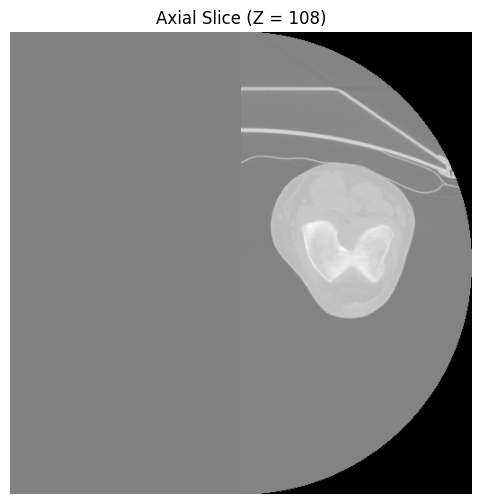

In [9]:
# axial view 
axial_slice_index = depth // 2
axial_slice = image[axial_slice_index, :, :]
show_slice(axial_slice, title=f'Axial Slice (Z = {axial_slice_index})')

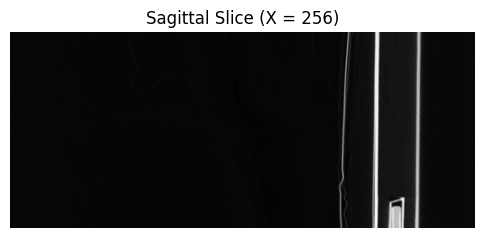

In [10]:
# sagittal view 
sagittal_slice_index = width // 2
sagittal_slice = image[:, :, sagittal_slice_index]
show_slice(sagittal_slice, title=f'Sagittal Slice (X = {sagittal_slice_index})')

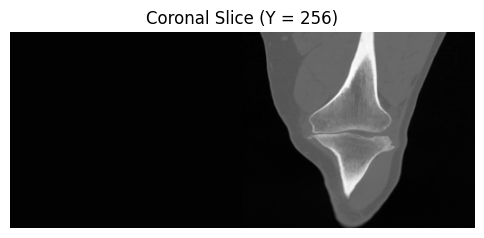

In [11]:
# coronal view 
coronal_slice_index = height // 2
coronal_slice = image[:, coronal_slice_index+1, :]
show_slice(coronal_slice, title=f'Coronal Slice (Y = {coronal_slice_index})')

### Segmentation

In [12]:
from skimage import measure
from scipy.ndimage import gaussian_filter1d
import cv2 

In [13]:
threshold_value = 190  
bone_mask = (coronal_slice > threshold_value).astype(np.uint8)

# cleanup
kernel = np.ones((7, 7), np.uint8)
bone_mask = cv2.morphologyEx(bone_mask, cv2.MORPH_CLOSE, kernel)
bone_mask = cv2.morphologyEx(bone_mask, cv2.MORPH_OPEN, kernel)


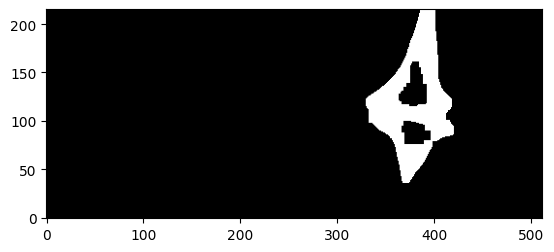

In [14]:
plt.imshow(bone_mask, cmap='gray', origin='lower')